# Setup

## Packages

In [1]:
from preamble import *
from natural_units_GeV import *
from macro_lens_functions import *
from sensitivity_functions import *
from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# import the lens model class 
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LensModel.lens_model_extensions import LensModelExtensions
# import the lens equation solver class (finding image plane positions of a source position)
from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver
# import lens model solver with 4 image positions constraints
from lenstronomy.LensModel.Solver.solver4point import Solver4Point
from lenstronomy.Plots.lens_plot import lens_model_plot
from lenstronomy.Util import util


 21%|██        | 105/500 [00:05<00:23, 17.15it/s]/Users/kvantilburg/Dropbox/projects/A2 astrometric-microlensing-quasars/quaDM_lens/code/sensitivity_functions.py:87: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  vec_F_x_k[i_k] = quad(lambda x_b: sp.special.jv(1,x_b) * int_m_x_b(x_b / x_k) / vec_m_x_b[-1],
  6%|▌         | 57/1000 [00:02<00:41, 22.91it/s]/Users/kvantilburg/Dropbox/projects/A2 astrometric-microlensing-quasars/quaDM_lens/code/sensitivity_functions.py:104: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  vec_F_x_k_integral_c[i_k] = quad(lambda phi: np.cos(2*phi) * (int_F_x_k(x_k / np.cos(phi)))**2,
 35%|███▌      | 353/1000 [00:14<00:48, 13.43it/s]/Users/kvantilburg/Dropbox/projects/A2 astrometric-microlensing-quasars/quaDM_lens/code/se

## Parameters

In [2]:
from params_B1422_231 import *

v_obs = np.asarray([0,0]) * km / second
v_lens = np.asarray([500,500]) * km / second
v_source = np.asarray([0,0]) * km / second

vec_mu_source = mu_rel(v_obs, v_lens, v_source, z_lens, z_source, d_lens, d_source, d_lens_source)

# observational errors
t_int = 10 * year
sigma_delta_theta = 0.1 * muas
N_obs = 100

theta: 
 [[ 0.386   0.3169]
 [ 0.      0.    ]
 [-0.336  -0.7516]
 [ 0.947  -0.8012]]
theta_500 =  0.053 muas = 0.260e-12 rad
theta_E_star =  1.400 muas


## Inputs from macro-lens model

In [3]:
filename = 'macro_lens_results.npz'
results = np.load(filename)

kappa_fit = results['kappa_fit']
gamma1_fit = results['gamma1_fit']
gamma2_fit = results['gamma2_fit']
mag_fit = results['mag_fit']
hessian_fit = results['hessian_fit']
jacobian_fit = results['jacobian_fit']
inv_jacobian_fit = results['inv_jacobian_fit']
eigvals_fit = results['eigvals_fit']
eigvecs_fit = results['eigvecs_fit']

In [4]:
fraction_l = 0.5
kappa_star = 0.02

In [5]:
kappa_l = kappa_fit * fraction_l # DM microlens convergence at image locations

vec_mu_tilde = np.tensordot(inv_jacobian_fit, vec_mu_source, axes=1) # lensed image proper motion vectors
mu_tilde = np.linalg.norm(vec_mu_tilde, axis=1) # lensed image proper motion magnitudes

# angle of vec_mu_tilde with respect to RA direction
zeta = np.arctan2(vec_mu_tilde[:,1], vec_mu_tilde[:,0])

print('kappa_l =', kappa_l)
print('mu_tilde =', mu_tilde / muasy, 'muas/yr')
print('zeta =', zeta / degree, 'degree')

kappa_l = [0.19239582 0.23139199 0.1834638  0.85749551]
mu_tilde = [0.80661555 1.13118003 0.41101606 0.04532126] muas/yr
zeta = [-148.93022801   49.75883342 -106.01927052   76.88231717] degree


# Analytic Power Spectrum

## Power in individual images

### Calculation

In [34]:
vec_omega = year**-1 * np.logspace(-3,3,int(1e3))
vec_M_200_l = np.asarray([1e3,1e0,1e-3]) * M_Solar
arr_C_ij_l = np.zeros((len(kappa_l),len(vec_M_200_l),2,2,len(vec_omega)))

vec_C_star = kappa_star * theta_E_star**2 / vec_omega * np.pi
arr_C_ij_star = np.asarray([[vec_C_star, np.zeros_like(vec_C_star)],[np.zeros_like(vec_C_star),vec_C_star]])

vec_C_EPIC = C_EPIC(vec_omega, t_int=t_int, N_obs=N_obs, sigma_delta_theta=sigma_delta_theta)

for j, M_200 in enumerate(vec_M_200_l):
    r_s = r_s_Einasto_200(M_200);
    rho_s = rho_s_Einasto_200(M_200); 
    M_l = M_Einasto(rho_s,r_s);
    gamma_l = r_s/d_lens;
    theta_E_l = theta_E(M_l, d_lens, d_source, d_lens_source)
    for i in range(len(kappa_l)):
        arr_C_ij_l[i,j] = kappa_l[i] * theta_E_l**2 / vec_omega * C_ij_integral(gamma_l/mu_tilde[i] * vec_omega, zeta[i])
arr_C_pq_l = np.einsum('aqj,abpjm->abpqm',inv_jacobian_fit, np.einsum('api,abijm->abpjm', inv_jacobian_fit, arr_C_ij_l)) # implement macrolensing of power spectrum

### Plots

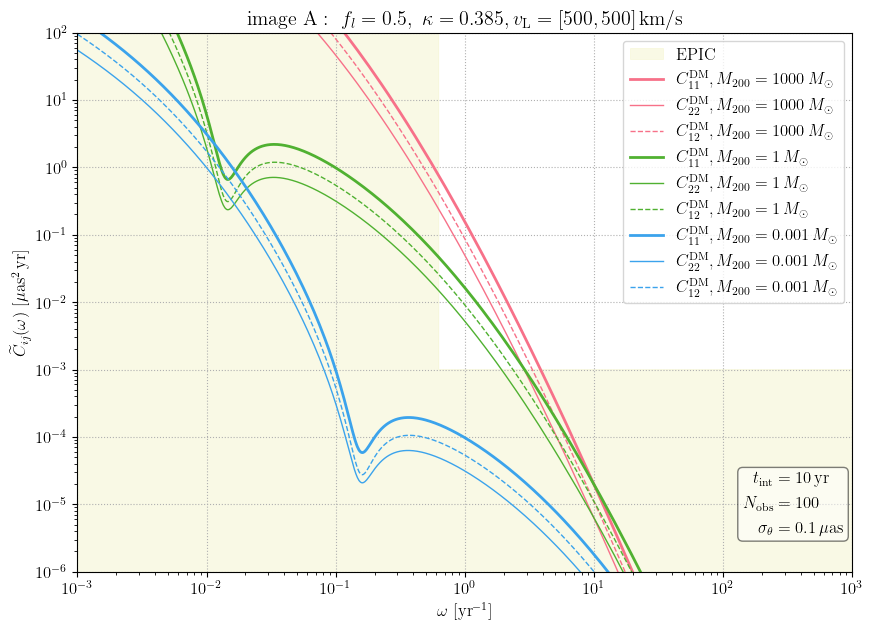

In [35]:
fig,ax = plt.subplots(1,1,figsize=(10,7))
colors = sns.color_palette("husl", 3)
ax.fill_between(vec_omega/year**-1,vec_C_EPIC/(muas**2*year),
                edgecolor=(0.8,0.8,0,1),color=(0.8,0.8,0,0.1), lw=0.5, label=r'$\mathrm{EPIC}$')
idx_l = 0
for i in [idx_l]:
        for j, M_200 in enumerate(vec_M_200_l):
                ax.plot(vec_omega/year**-1, arr_C_pq_l[i,j,0,0]/(muas**2*year), color=colors[j], lw=2, 
                        label=r'$C^\mathrm{DM}_{11}, M_{200} = %.5g \, M_\odot$' % (M_200/M_Solar))
                ax.plot(vec_omega/year**-1, arr_C_pq_l[i,j,1,1]/(muas**2*year), color=colors[j], lw=1, 
                        label=r'$C^\mathrm{DM}_{22}, M_{200} = %.5g \, M_\odot$' % (M_200/M_Solar))
                ax.plot(vec_omega/year**-1, np.abs(arr_C_pq_l[i,j,0,1])/(muas**2*year), color=colors[j],lw=1,ls='dashed', 
                        label=r'$C^\mathrm{DM}_{12}, M_{200} = %.5g \, M_\odot$' % (M_200/M_Solar))
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\omega~ [\mathrm{yr}^{-1}$]')
ax.set_ylabel(r'$\widetilde{C}_{ij}(\omega) ~[\mathrm{\mu as^2 \, yr}]$')
ax.grid(ls='dotted')
ax.set_xlim(1e-3,1e3);
ax.set_ylim(1e-6,1e2)
ax.legend();
ax.text(0.85e3,1e-5,
        r'\begin{align*} t_\mathrm{int} &= %.5g \,\mathrm{yr} \\ N_\mathrm{obs} &= %.5g \\ \sigma_\theta &= %.5g \, \mathrm{ \mu as} \end{align*}'
        % ((t_int/year),(N_obs),(sigma_delta_theta/muas)),
        ha='right',va='center',bbox=dict(boxstyle='round', facecolor='white', alpha=0.5));
ax.set_title(r'$\text{image}~\mathrm{%s}: ~f_l = %.1g, ~\kappa = %.3g, v_\mathrm{L} = [%.3g,%.3g] \,\mathrm{km/s}$' % (labels[idx_l], fraction_l, kappa_fit[idx_l], (v_lens[0]/(km/second)), (v_lens[1]/(km/second))));

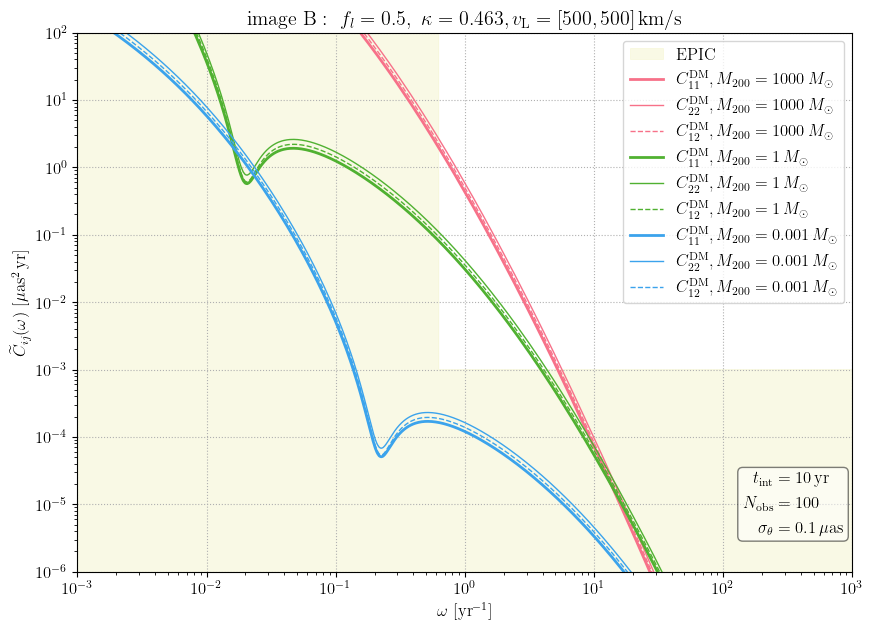

In [36]:
fig,ax = plt.subplots(1,1,figsize=(10,7))
colors = sns.color_palette("husl", 3)
ax.fill_between(vec_omega/year**-1,vec_C_EPIC/(muas**2*year),
                edgecolor=(0.8,0.8,0,1),color=(0.8,0.8,0,0.1), lw=0.5, label=r'$\mathrm{EPIC}$')
idx_l = 1
for i in [idx_l]:
        for j, M_200 in enumerate(vec_M_200_l):
                ax.plot(vec_omega/year**-1, arr_C_pq_l[i,j,0,0]/(muas**2*year), color=colors[j], lw=2, 
                        label=r'$C^\mathrm{DM}_{11}, M_{200} = %.5g \, M_\odot$' % (M_200/M_Solar))
                ax.plot(vec_omega/year**-1, arr_C_pq_l[i,j,1,1]/(muas**2*year), color=colors[j], lw=1, 
                        label=r'$C^\mathrm{DM}_{22}, M_{200} = %.5g \, M_\odot$' % (M_200/M_Solar))
                ax.plot(vec_omega/year**-1, np.abs(arr_C_pq_l[i,j,0,1])/(muas**2*year), color=colors[j],lw=1,ls='dashed', 
                        label=r'$C^\mathrm{DM}_{12}, M_{200} = %.5g \, M_\odot$' % (M_200/M_Solar))
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\omega~ [\mathrm{yr}^{-1}$]')
ax.set_ylabel(r'$\widetilde{C}_{ij}(\omega) ~[\mathrm{\mu as^2 \, yr}]$')
ax.grid(ls='dotted')
ax.set_xlim(1e-3,1e3);
ax.set_ylim(1e-6,1e2)
ax.legend();
ax.text(0.85e3,1e-5,
        r'\begin{align*} t_\mathrm{int} &= %.5g \,\mathrm{yr} \\ N_\mathrm{obs} &= %.5g \\ \sigma_\theta &= %.5g \, \mathrm{ \mu as} \end{align*}'
        % ((t_int/year),(N_obs),(sigma_delta_theta/muas)),
        ha='right',va='center',bbox=dict(boxstyle='round', facecolor='white', alpha=0.5));
ax.set_title(r'$\text{image}~\mathrm{%s}: ~f_l = %.1g, ~\kappa = %.3g, v_\mathrm{L} = [%.3g,%.3g] \,\mathrm{km/s}$' % (labels[idx_l], fraction_l, kappa_fit[idx_l], (v_lens[0]/(km/second)), (v_lens[1]/(km/second))));

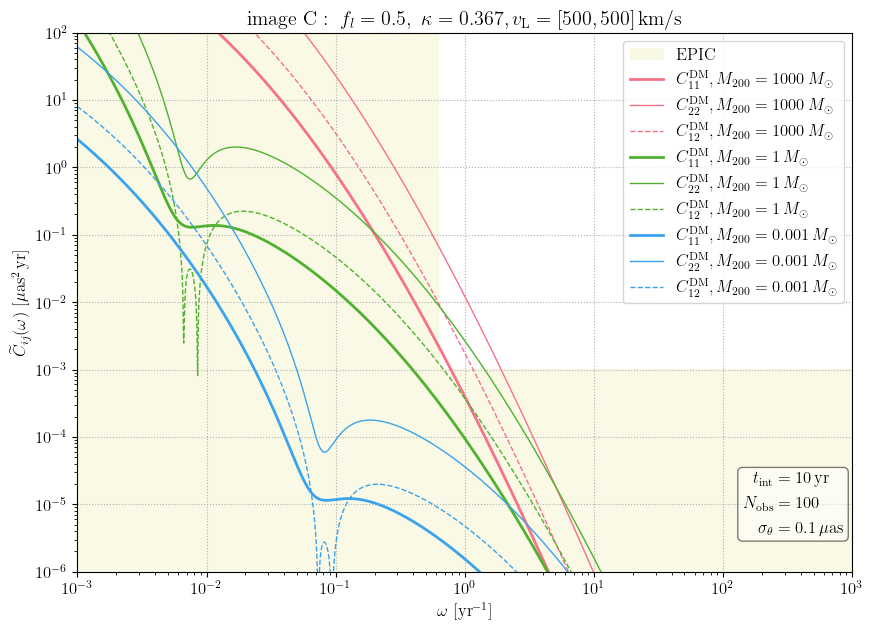

In [37]:
fig,ax = plt.subplots(1,1,figsize=(10,7))
colors = sns.color_palette("husl", 3)
ax.fill_between(vec_omega/year**-1,vec_C_EPIC/(muas**2*year),
                edgecolor=(0.8,0.8,0,1),color=(0.8,0.8,0,0.1), lw=0.5, label=r'$\mathrm{EPIC}$')
idx_l = 2
for i in [idx_l]:
        for j, M_200 in enumerate(vec_M_200_l):
                ax.plot(vec_omega/year**-1, arr_C_pq_l[i,j,0,0]/(muas**2*year), color=colors[j], lw=2, 
                        label=r'$C^\mathrm{DM}_{11}, M_{200} = %.5g \, M_\odot$' % (M_200/M_Solar))
                ax.plot(vec_omega/year**-1, arr_C_pq_l[i,j,1,1]/(muas**2*year), color=colors[j], lw=1, 
                        label=r'$C^\mathrm{DM}_{22}, M_{200} = %.5g \, M_\odot$' % (M_200/M_Solar))
                ax.plot(vec_omega/year**-1, np.abs(arr_C_pq_l[i,j,0,1])/(muas**2*year), color=colors[j],lw=1,ls='dashed', 
                        label=r'$C^\mathrm{DM}_{12}, M_{200} = %.5g \, M_\odot$' % (M_200/M_Solar))
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\omega~ [\mathrm{yr}^{-1}$]')
ax.set_ylabel(r'$\widetilde{C}_{ij}(\omega) ~[\mathrm{\mu as^2 \, yr}]$')
ax.grid(ls='dotted')
ax.set_xlim(1e-3,1e3);
ax.set_ylim(1e-6,1e2)
ax.legend();
ax.text(0.85e3,1e-5,
        r'\begin{align*} t_\mathrm{int} &= %.5g \,\mathrm{yr} \\ N_\mathrm{obs} &= %.5g \\ \sigma_\theta &= %.5g \, \mathrm{ \mu as} \end{align*}'
        % ((t_int/year),(N_obs),(sigma_delta_theta/muas)),
        ha='right',va='center',bbox=dict(boxstyle='round', facecolor='white', alpha=0.5));
ax.set_title(r'$\text{image}~\mathrm{%s}: ~f_l = %.1g, ~\kappa = %.3g, v_\mathrm{L} = [%.3g,%.3g] \,\mathrm{km/s}$' % (labels[idx_l], fraction_l, kappa_fit[idx_l], (v_lens[0]/(km/second)), (v_lens[1]/(km/second))));

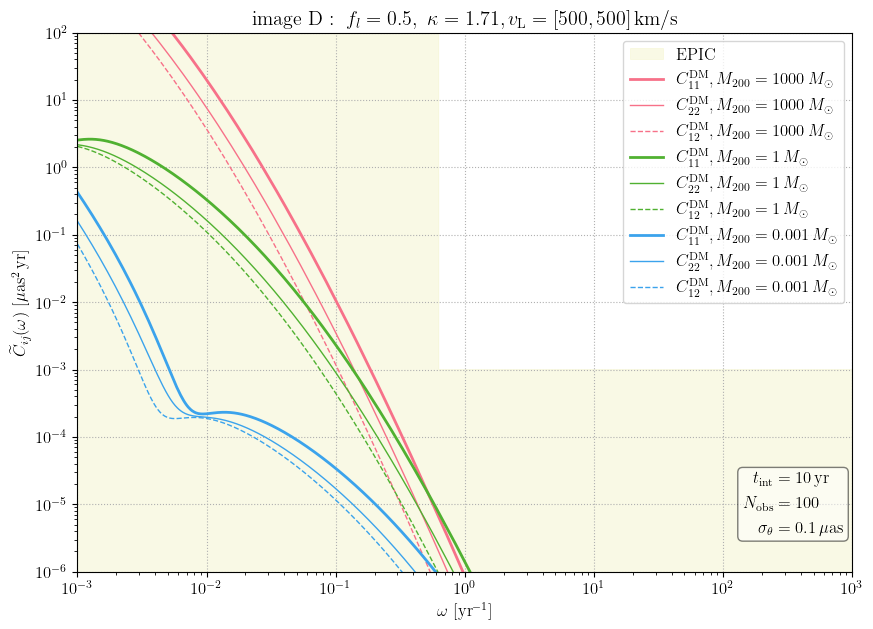

In [38]:
fig,ax = plt.subplots(1,1,figsize=(10,7))
colors = sns.color_palette("husl", 3)
ax.fill_between(vec_omega/year**-1,vec_C_EPIC/(muas**2*year),
                edgecolor=(0.8,0.8,0,1),color=(0.8,0.8,0,0.1), lw=0.5, label=r'$\mathrm{EPIC}$')
idx_l = 3
for i in [idx_l]:
        for j, M_200 in enumerate(vec_M_200_l):
                ax.plot(vec_omega/year**-1, arr_C_pq_l[i,j,0,0]/(muas**2*year), color=colors[j], lw=2, 
                        label=r'$C^\mathrm{DM}_{11}, M_{200} = %.5g \, M_\odot$' % (M_200/M_Solar))
                ax.plot(vec_omega/year**-1, arr_C_pq_l[i,j,1,1]/(muas**2*year), color=colors[j], lw=1, 
                        label=r'$C^\mathrm{DM}_{22}, M_{200} = %.5g \, M_\odot$' % (M_200/M_Solar))
                ax.plot(vec_omega/year**-1, np.abs(arr_C_pq_l[i,j,0,1])/(muas**2*year), color=colors[j],lw=1,ls='dashed', 
                        label=r'$C^\mathrm{DM}_{12}, M_{200} = %.5g \, M_\odot$' % (M_200/M_Solar))
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\omega~ [\mathrm{yr}^{-1}$]')
ax.set_ylabel(r'$\widetilde{C}_{ij}(\omega) ~[\mathrm{\mu as^2 \, yr}]$')
ax.grid(ls='dotted')
ax.set_xlim(1e-3,1e3);
ax.set_ylim(1e-6,1e2)
ax.legend();
ax.text(0.85e3,1e-5,
        r'\begin{align*} t_\mathrm{int} &= %.5g \,\mathrm{yr} \\ N_\mathrm{obs} &= %.5g \\ \sigma_\theta &= %.5g \, \mathrm{ \mu as} \end{align*}'
        % ((t_int/year),(N_obs),(sigma_delta_theta/muas)),
        ha='right',va='center',bbox=dict(boxstyle='round', facecolor='white', alpha=0.5));
ax.set_title(r'$\text{image}~\mathrm{%s}: ~f_l = %.1g, ~\kappa = %.3g, v_\mathrm{L} = [%.3g,%.3g] \,\mathrm{km/s}$' % (labels[idx_l], fraction_l, kappa_fit[idx_l], (v_lens[0]/(km/second)), (v_lens[1]/(km/second))));

# Sensitivity

## Instrument-limited

\begin{align}
C^\mathrm{AB}_{ij} = \langle (\theta^\mathrm{A}_i - \theta^\mathrm{B}_i) (\theta^\mathrm{A}_j - \theta^\mathrm{B}_j) \rangle = C^\mathrm{A}_{ij} + C^\mathrm{B}_{ij}
\end{align}

Compute eigenvalue of $C_{ij}^\mathrm{AB}$, compare largest to $C_{ii}^\mathrm{EPIC}$ (no sum). When SNR > 1, that parameter space point of $\kappa_l$, $M_l$, $r_s$ is detectable.

Fixed velocity for now, marginalize over velocity later.



### Scan

In [52]:
list_r_s = 10**np.arange(-3.5,1,0.05) * pc
list_rho_s = 10**np.arange(-1.,4.01,0.05) * M_Solar/pc**3
arr_r_s, arr_rho_s = np.meshgrid(list_r_s, list_rho_s)
arr_crit = Sigma_Einasto(arr_r_s, arr_rho_s, arr_r_s) / Sigma_crit(d_lens, d_source, d_lens_source)
arr_M_s = np.asarray([[M_enc_Einasto(r_s, rho_s, r_s) for r_s in list_r_s] for rho_s in list_rho_s])
arr_M_l = np.asarray([[M_Einasto(rho_s, r_s) for r_s in list_r_s] for rho_s in list_rho_s])
arr_gamma_l = arr_r_s / d_lens
arr_theta_E_l = theta_E(arr_M_l, d_lens, d_source, d_lens_source)
list_omega = year**-1 * np.logspace(-1,2,int(1e2))

arr_C_ij_l = np.zeros((len(kappa_l),len(list_rho_s),len(list_r_s),2,2,len(list_omega)))
for i in range(len(kappa_l)):
    arr_C_ij_l[i] = kappa_l[i] * arr_theta_E_l[:,:,None,None,None]**2 / list_omega * np.transpose(C_ij_integral(arr_gamma_l[:,:,None]/mu_tilde[i] * list_omega, zeta[i]),axes=(2,3,0,1,4))
arr_C_pq_l = np.einsum('aqj,abcpjm->abcpqm',inv_jacobian_fit, np.einsum('api,abcijm->abcpjm', inv_jacobian_fit, arr_C_ij_l)) # implement macrolensing of power spectrum

# added power spectra for all image pairs
N_images = len(kappa_l)
N_pairs = N_images * (N_images - 1) // 2
arr_Delta_C_pq_l = np.zeros((N_pairs,len(list_rho_s),len(list_r_s),2,2,len(list_omega))) # shape = N_pairs, len(list_rho_s), len(list_r_s), 2, 2,  len(list_omega)

count = 0
for i in range(N_images):
    for j in range(i+1,N_images):
        arr_Delta_C_pq_l[count] = arr_C_pq_l[i] + arr_C_pq_l[j]
        count+=1

arr_Delta_C_pq_l = np.transpose(arr_Delta_C_pq_l, axes=(1,2,0,5,3,4)) # reshape = len(list_rho_s), len(list_r_s), N_pairs, len(list_omega), 2, 2
arr_Delta_C_mag_l = np.max(np.linalg.eigvals(arr_Delta_C_pq_l),axis=-1) # magnitude of largest eigenvalue

arr_C_EPIC = C_EPIC(list_omega, t_int=t_int, N_obs=N_obs, sigma_delta_theta=sigma_delta_theta) #[None,None,None,:]

arr_SNR_EPIC = np.max(arr_Delta_C_mag_l / arr_C_EPIC, axis=(-2,-1))

### Plot

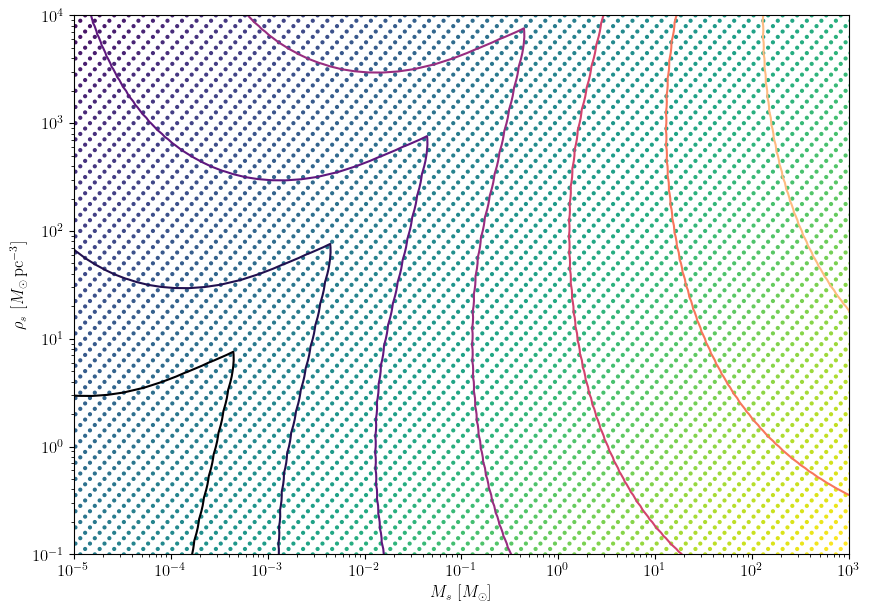

In [44]:
fig,ax = plt.subplots(1,1,figsize=(10,7))
ax.scatter(arr_M_s/M_Solar, arr_rho_s/(M_Solar/pc**3), c=np.log10(arr_r_s/pc), cmap='viridis', s=4);
cs_SNR = ax.contour(arr_M_s/M_Solar, arr_rho_s/(M_Solar/pc**3), np.log10(arr_SNR_EPIC), cmap='magma', levels=range(0,8))
cs_crit = ax.contour(arr_M_s/M_Solar, 
#ax.clabel(cs, inline=True, fontsize=20)
ax.set_xlim(1e-5,1e3);
ax.set_ylim(1e-1,1e4);
ax.set_xscale('log');
ax.set_yscale('log');
ax.set_xlabel(r'$M_s~[M_\odot]$');
ax.set_ylabel(r'$\rho_s~[M_\odot \, \mathrm{pc}^{-3}]$');


# Scratch

In [145]:
M_200 = 0.1 * M_Solar
fac = 100
r_s = (fac**(-1/3))*r_s_Einasto_200(M_200);
rho_s = fac*rho_s_Einasto_200(M_200); 
M_l = M_Einasto(rho_s,r_s);
M_s = M_enc_Einasto(r_s, rho_s, r_s);
gamma_l = r_s/d_lens;
theta_E_l = theta_E(M_l, d_lens, d_source, d_lens_source)
print('M_l =', M_l/M_Solar, 'M_Solar')
print('M_s =', M_s/M_Solar, 'M_Solar')
print('rho_s =', rho_s/(M_Solar/pc**3), 'M_Solar/pc^3')
print('gamma_l =', gamma_l)
print('theta_E_l =', theta_E_l)

M_star = 0.4 * M_Solar
theta_E_star = theta_E(M_star, d_lens, d_source, d_lens_source)
gamma_star = 100 * theta_E_star
print('theta_E_star =', theta_E_star)

M_l = 0.13508270051896545 M_Solar
M_s = 0.007938370096623968 M_Solar
rho_s = 1.9445357969426267 M_Solar/pc^3
gamma_l = 7.328775214224465e-11
theta_E_l = 4.556485889048088e-12
theta_E_star = 7.840796063834002e-12


(100000000.0, 1000000000000.0)

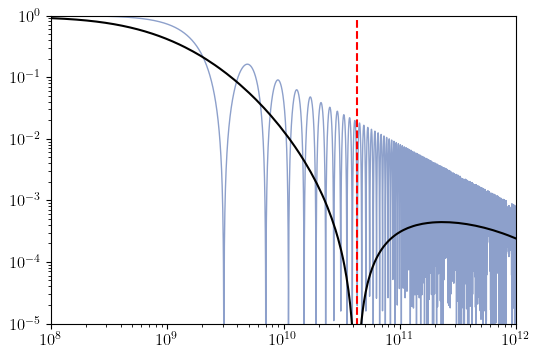

In [142]:
colors = sns.color_palette("Set2", 3)
fig,ax = plt.subplots(1,1,figsize=(6,4))
vec_k = np.logspace(8,12,int(4e3))
ax.plot(vec_k, sp.special.j0(vec_k * gamma_star)**2,lw=1,color=colors[2])
ax.vlines(np.pi/gamma_l,1e-6,1,color='red',ls='dashed')
ax.plot(vec_k, int_F_x_k(vec_k * gamma_l)**2,color='k')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(1e-5,1)
ax.set_xlim(1e8,1e12)

In [51]:
r_s = 1 * pc
rho_s = 1 * M_Solar / pc**3
Sigma_Einasto(np.linspace(0.00001,10,20) * r_s, rho_s, r_s) / Sigma_crit(d_lens, d_source, d_lens_source)

array([0.00000000e+00, 2.62374163e-03, 1.24290747e-03, 7.50964262e-04,
       5.08429044e-04, 3.68395769e-04, 2.79435376e-04, 2.19087955e-04,
       1.76167273e-04, 1.44490400e-04, 1.20468314e-04, 1.01790450e-04,
       8.70014528e-05, 7.50839736e-05, 6.53556719e-05, 5.73190319e-05,
       5.05908272e-05, 4.49313345e-05, 4.01115625e-05, 3.59796191e-05])